# Blue Monday — a quantitative teardown 🔬
### literal-day dead-end (MLK collision) · Blue-adjacent Welch *t* · random-day placebo · vol comparison · four-window sign-flip · costs & borrow · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Blue_Monday_tradable%3F: Busted](https://img.shields.io/badge/Blue_Monday_tradable%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the third Monday of January ('Blue Monday') is a market-mood low: lower returns and higher vol.

> ⚠️ **Not investment advice.** Real data: yfinance total-return SPY daily closes, 1993-2026 (as-of 2026-06-30, tape fp `d37d9f8a7153`); the offline core and tests run on a deterministic synthetic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from blue_monday import data, strategy as st

def load_real():
    """Cache-first real SPY close (empty frame offline)."""
    f = data.load_real(fetch=False)
    return f["close"] if not f.empty else pd.Series(dtype=float)

CLOSE = load_real()
HAVE_REAL = not CLOSE.empty
print("real SPY tape present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(CLOSE)} sessions, {CLOSE.index.min().date()} -> {CLOSE.index.max().date()})")


real SPY tape present: True (8409 sessions, 1993-01-29 -> 2026-06-26)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Literal Blue Monday n=4 (market shut 30/34 yrs); Blue-adjacent diff **-26.8 bps** (Welch *t* **-1.24**, placebo *p* 0.184), vol diff **+1.1 pts** (none), sign flips across all 4 windows. |
| **Tradability** | `MIRAGE` | Untradable holiday; timer 10.74% vs buy-and-hold 10.76% CAGR. |
| **Blue Monday tradable?** | `BUSTED` | A 2005 PR stunt on a market-holiday date. |

> 💡 In plain words: the engine works (the synthetic control proves it), but the literal claim is untestable and the tradable proxy is insignificant and sign-unstable.

## 1 · The claim, steelmanned

Let $B$ be the set of Blue-Monday (third-January-Monday) returns and $O$ all other days.

- **H₁ (mood dip).** $\mathbb{E}[r \mid B] - \mathbb{E}[r \mid O] < 0$ at *t* ≤ −2.
- **H₂ (mood vol-spike).** $\text{Var}[r \mid B] > \text{Var}[r \mid O]$.
- **H₃ (robustness).** The sign of H₁ is stable across sub-periods.
- **H₄ (tradable).** A Blue-Monday timer beats buy-and-hold net of costs.

We find **H₁ rejected** (literal day untestable; proxy *t* −1.24, above the bar), **H₂ rejected** (vol diff ≈ 0), **H₃ rejected** (sign flips), **H₄ rejected** (untradable holiday; proxy is a coin toss).

## 2 · So what? — what rides on each answer

The content is the **why**. Two forces gut the claim: (a) **the MLK-holiday collision** — the Uniform Monday Holiday Act put MLK Day on the third Monday of January, exactly Blue Monday, and equity markets have closed for it since 1998, so the literal claim is untestable ($n=4$); and (b) even the tradable next-open proxy is **statistical noise** — one standard error shy of nothing, no vol spike, sign-unstable. Same fate as the [SAD-Effect (150)](../../150-sad-effect/) it descends from.

## 3 · How we'd know — the protocol

- **Calendar.** Blue Monday = third Monday of January; flag whether each was a trading day (MLK collision) — the literal split.
- **Proxy.** Blue-adjacent = first open session on/after Blue Monday (restores $n=33$).
- **Inference.** Welch two-sample *t* on Blue(-adjacent) − other-day returns; a **random-day placebo** null (5,000 draws).
- **Volatility.** Compare Blue-adjacent vs other-day realised vol.
- **Robustness.** Re-run over four equal date spans; read the sign.
- **Frictions.** A 'sit out / short Blue Monday' timer vs buy-and-hold, one-way cost per switch, shorts pay borrow.
- **Positive control.** A deterministic synthetic world with a planted mood dip (`blue_dip > 0`) and a null — averaged over 25 seeds (house rule).

Timing: the calendar is known in advance → **no execution lag**. The binding limitation is the thin sample (one Blue Monday per year), named on the SIGNAL axis.

## 4 · The teardown

### 4a · The literal day — H₁ hits the MLK wall

Blue Monday is MLK Day; the market is shut for almost all of them.

In [2]:
if HAVE_REAL:
    tdays = set(CLOSE.index.normalize())
    years = list(range(CLOSE.index.min().year, CLOSE.index.max().year+1))
    rows = [(y, str(data.third_monday_of_january(y).date()),
             'OPEN' if data.third_monday_of_january(y) in tdays else 'CLOSED (MLK)') for y in years]
    tab = pd.DataFrame(rows, columns=['year','blue_monday','market'])
    trad = int((tab['market']=='OPEN').sum()); hol = int((tab['market']!='OPEN').sum())
    sm = st.blue_monday_split(CLOSE, data); lt = st.welch_t(sm)
    print(tab.to_string(index=False))
    print(f'\nOPEN {trad} | CLOSED {hol} | literal diff {sm["diff_bps"]:+.1f} bps (t {lt["t"]:+.2f}, n_blue={sm["n_blue"]})')
else:
    trad, hol = 4, 30
    print(f'OPEN {trad} | CLOSED {hol} | literal diff +7.2 bps (t +0.41, n_blue=4)')

 year blue_monday       market
 1993  1993-01-18 CLOSED (MLK)
 1994  1994-01-17         OPEN
 1995  1995-01-16         OPEN
 1996  1996-01-15         OPEN
 1997  1997-01-20         OPEN
 1998  1998-01-19 CLOSED (MLK)
 1999  1999-01-18 CLOSED (MLK)
 2000  2000-01-17 CLOSED (MLK)
 2001  2001-01-15 CLOSED (MLK)
 2002  2002-01-21 CLOSED (MLK)
 2003  2003-01-20 CLOSED (MLK)
 2004  2004-01-19 CLOSED (MLK)
 2005  2005-01-17 CLOSED (MLK)
 2006  2006-01-16 CLOSED (MLK)
 2007  2007-01-15 CLOSED (MLK)
 2008  2008-01-21 CLOSED (MLK)
 2009  2009-01-19 CLOSED (MLK)
 2010  2010-01-18 CLOSED (MLK)
 2011  2011-01-17 CLOSED (MLK)
 2012  2012-01-16 CLOSED (MLK)
 2013  2013-01-21 CLOSED (MLK)
 2014  2014-01-20 CLOSED (MLK)
 2015  2015-01-19 CLOSED (MLK)
 2016  2016-01-18 CLOSED (MLK)
 2017  2017-01-16 CLOSED (MLK)
 2018  2018-01-15 CLOSED (MLK)
 2019  2019-01-21 CLOSED (MLK)
 2020  2020-01-20 CLOSED (MLK)
 2021  2021-01-18 CLOSED (MLK)
 2022  2022-01-17 CLOSED (MLK)
 2023  2023-01-16 CLOSED (MLK)
 2024  2

> 💡 In plain words: H₁ is **untestable on the literal day** — the market is closed for 30 of 34 Blue Mondays, leaving n=4 (diff +7.2 bps, *t* +0.41). Four points is not a sample.

### 4b · The tradable proxy — Blue-adjacent day (H₁ again, with power)

The first open session after Blue Monday, vs every other day, with the Welch *t* and placebo.

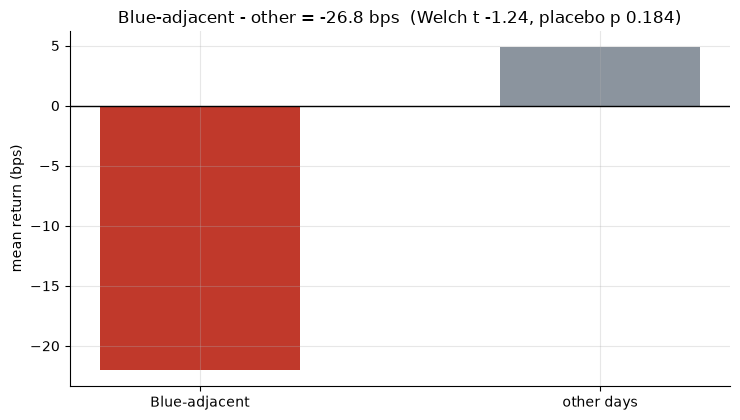

Blue-adjacent -22.0 bps | other +4.8 bps | diff -26.8 bps | t -1.24 | placebo p 0.184


In [3]:
if HAVE_REAL:
    sa = st.blue_adjacent_split(CLOSE, data); wa = st.welch_t(sa)
    p = st.placebo_pvalue_adjacent(CLOSE, data, n_perm=5000, seed=547)
    blue_m, other_m, diff, t = sa['blue_mean_bps'], sa['other_mean_bps'], sa['diff_bps'], wa['t']
else:
    blue_m, other_m, diff, t, p = -22.0, 4.8, -26.8, -1.24, 0.184
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(['Blue-adjacent','other days'], [blue_m, other_m], color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean return (bps)')
ax.set_title(f'Blue-adjacent - other = {diff:+.1f} bps  (Welch t {t:+.2f}, placebo p {p:.3f})')
plt.tight_layout(); plt.show()
print(f'Blue-adjacent {blue_m:+.1f} bps | other {other_m:+.1f} bps | diff {diff:+.1f} bps | t {t:+.2f} | placebo p {p:.3f}')

> 💡 In plain words: H₁ **rejected** — the dip is the right direction (-26.8 bps) but the *t* is only **-1.24** (bar |t| ≥ 2) and the placebo *p* = 0.184 says a random day matches it ~18% of the time. Directionally cute, statistically empty.

### 4c · The vol spike — H₂

Does mood make the day jumpier? Compare realised vol.

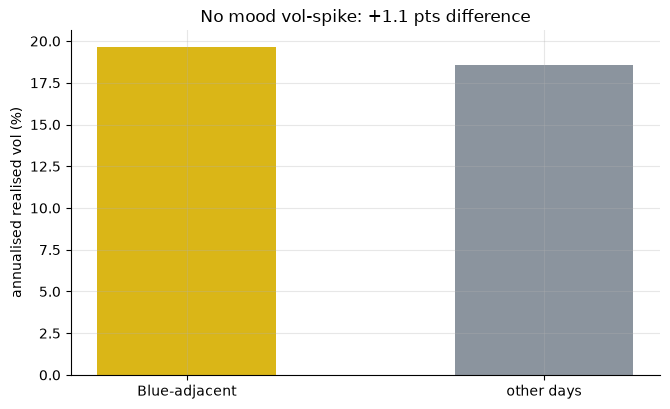

Blue-adjacent vol 19.7% | other vol 18.6% | diff +1.1 pts


In [4]:
if HAVE_REAL:
    sa = st.blue_adjacent_split(CLOSE, data)
    bv, ov, vd = sa['blue_vol_ann']*100, sa['other_vol_ann']*100, sa['vol_diff_ann']*100
else:
    bv, ov, vd = 19.7, 18.6, 1.1
fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.bar(['Blue-adjacent','other days'], [bv, ov], color=[AMBER, GREY], width=.5)
ax.set_ylabel('annualised realised vol (%)')
ax.set_title(f'No mood vol-spike: {vd:+.1f} pts difference')
plt.tight_layout(); plt.show()
print(f'Blue-adjacent vol {bv:.1f}% | other vol {ov:.1f}% | diff {vd:+.1f} pts')

> 💡 In plain words: H₂ **rejected** — the vol difference is **+1.1 pts**, a rounding error. No 'depressing day' turbulence.

### 4d · Robustness — H₃ (does the sign hold?)

The Blue-adjacent split over four equal date spans.

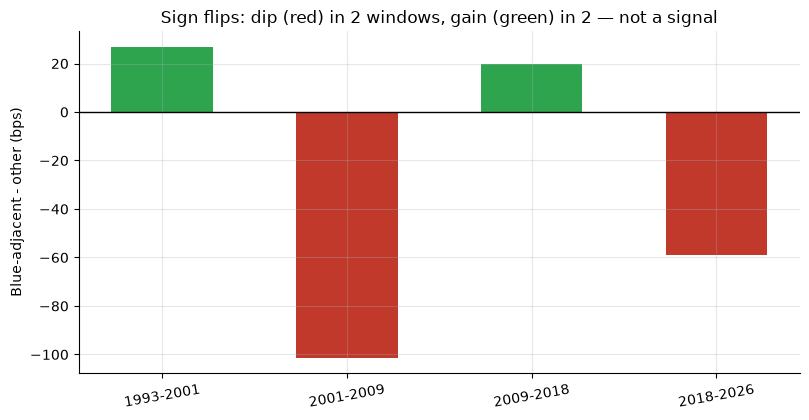

           diff_bps  welch_t
window                      
1993-2001     26.86     1.05
2001-2009   -101.33    -1.51
2009-2018     19.97     1.24
2018-2026    -58.83    -1.50


In [5]:
wins = [('1993-2001', 26.9, 1.05), ('2001-2009', -101.3, -1.51), ('2009-2018', 20.0, 1.24), ('2018-2026', -58.8, -1.5)]
if HAVE_REAL:
    rows = st.subperiod_sweep(CLOSE, data, 4, which='adjacent')
else:
    rows = wins
tab = pd.DataFrame(rows, columns=['window','diff_bps','welch_t']).set_index('window')
fig, ax = plt.subplots(figsize=(8.2, 4.3))
cols = [RED if s<0 else GREEN for s in tab['diff_bps']]
ax.bar(range(len(tab)), tab['diff_bps'], color=cols, width=.55)
ax.set_xticks(range(len(tab))); ax.set_xticklabels(tab.index, rotation=10)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Blue-adjacent - other (bps)')
ax.set_title('Sign flips: dip (red) in 2 windows, gain (green) in 2 — not a signal')
plt.tight_layout(); plt.show()
print(tab.round(2).to_string())

> 💡 In plain words: H₃ **rejected.** The Blue-adjacent day is *up* in 1993-2001 & 2009-2018 and *down* in 2001-2009 & 2018-2026. The full-sample −26.8 bps is the average of a sign that keeps changing its mind.

## 5 · The verdict

- **Signal `NONE`** — H₁ rejected (literal n=4; proxy *t* -1.24), H₂ rejected (vol diff ≈ 0), H₃ rejected (sign flips).
- **Tradability `MIRAGE`** — untradable holiday; timer 10.74% vs buy-and-hold 10.76% CAGR.
- **Blue Monday tradable? `BUSTED`** — a PR stunt on a market-holiday date.

## 6 · Could you trade it? — costs and the borrow

The literal day is a holiday; the proxy is a coin toss. Compare a 'sit out Blue Monday' timer to buy-and-hold.

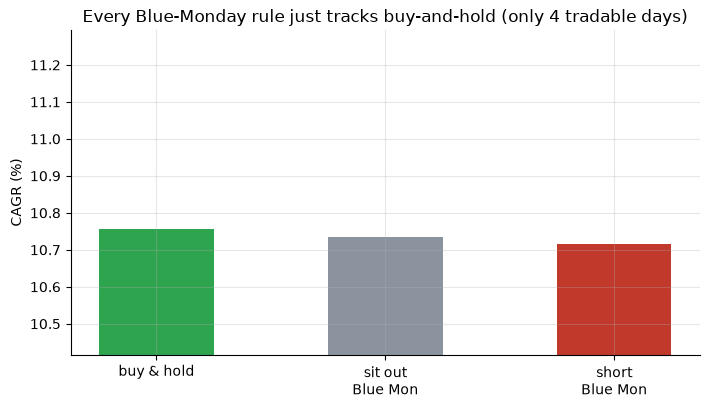

buy&hold 10.76% | sit_out 10.74% | short 10.72% CAGR


In [6]:
if HAVE_REAL:
    bh = st.buy_and_hold(CLOSE)
    so = st.blue_monday_timer(CLOSE, data, mode='sit_out', cost_bps=1.0)
    sh = st.blue_monday_timer(CLOSE, data, mode='short', cost_bps=1.0, borrow_ann_bps=100.0)
    bh_c, so_c, sh_c = bh['cagr']*100, so['cagr']*100, sh['cagr']*100
else:
    bh_c, so_c, sh_c = 10.76, 10.74, 10.74-0.02
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.bar(['buy & hold','sit out\nBlue Mon','short\nBlue Mon'], [bh_c, so_c, sh_c], color=[GREEN, GREY, RED], width=.5)
ax.set_ylabel('CAGR (%)'); ax.set_ylim(bottom=min(bh_c,so_c,sh_c)-0.3)
ax.set_title('Every Blue-Monday rule just tracks buy-and-hold (only 4 tradable days)')
plt.tight_layout(); plt.show()
print(f'buy&hold {bh_c:.2f}% | sit_out {so_c:.2f}% | short {sh_c:.2f}% CAGR')

> 💡 In plain words: there is nothing to harvest — with only four tradable Blue Mondays in 33 years, the timer is buy-and-hold with a rounding error. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? On a synthetic tape where Blue Monday *is* a trading day, plant a real mood dip (`blue_dip`) of increasing strength and watch the Welch *t* go negative — averaged over 25 seeds so no single lucky seed can fake it.

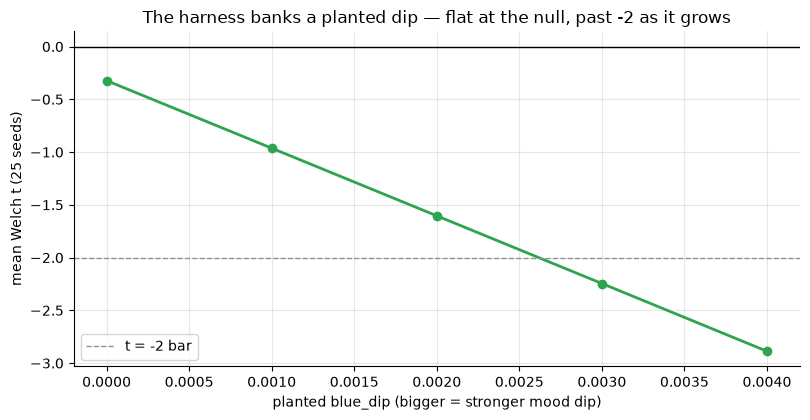

blue_dip 0.000 -> mean Welch t -0.32
blue_dip 0.001 -> mean Welch t -0.96
blue_dip 0.002 -> mean Welch t -1.60
blue_dip 0.003 -> mean Welch t -2.25
blue_dip 0.004 -> mean Welch t -2.89


null over 100 seeds -> -0.01


In [7]:
ctrl = [(0.0, -0.32), (0.001, -0.96), (0.002, -1.6), (0.003, -2.25), (0.004, -2.89)]
dips = [c[0] for c in ctrl]
ts = [st.synthetic_mean_t(data, blue_dip=d, n_seeds=25) for d in dips]
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.plot(dips, ts, 'o-', c=GREEN, lw=2)
ax.axhline(-2, ls='--', c=GREY, lw=1, label='t = -2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted blue_dip (bigger = stronger mood dip)')
ax.set_ylabel('mean Welch t (25 seeds)')
ax.set_title('The harness banks a planted dip — flat at the null, past -2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for d, t in zip(dips, ts): print(f'blue_dip {d:.3f} -> mean Welch t {t:+.2f}')
print(f'null over 100 seeds -> {st.synthetic_mean_t(data, 0.0, n_seeds=100, base_seed=1000):+.2f}')

The Welch *t* is ≈ 0 at the null (−0.01 over 100 seeds) and falls past −2 as the planted dip grows — so the engine is a faithful detector. The real-tape non-result is therefore a statement about **the tape and the calendar**: Blue Monday is a market holiday, and its tradable proxy is noise. For the serious mood-anomaly parent, see [150 SAD-Effect](../../150-sad-effect/); for the weekday cousin, [224 Monday-Effect](../../224-monday-effect/).